# Q3 Feature Engineering and Regression Pipeline

In [1]:
# 1.Date Feature Engineering
import pandas as pd

# Load dataset
df = pd.read_csv(r"E:\BA.GENAI\ml-assessment-kirankumari\data\q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Binary feature — is_month_end
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added successfully!")
print("Shape:", df.shape)

# Confirm new columns
sample_cols = ['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']
print(df[sample_cols].sample(5, random_state=42))

New columns added successfully!
Shape: (1200, 13)
     transaction_date  year  month  day_of_week  is_month_end
1178       2024-12-10  2024     12            1             0
865        2024-03-25  2024      3            0             1
101        2022-03-19  2022      3            5             0
439        2023-02-24  2023      2            4             0
58         2022-02-09  2022      2            2             0


In [2]:
# 2. Temporal Train-Test Split
# Sort by transaction_date
df = df.sort_values('transaction_date').reset_index(drop=True)

print("Date range:")
print("  Start:", df['transaction_date'].min())
print("  End  :", df['transaction_date'].max())
print("  Total records:", len(df))

# Split index — 80% train, 20% test
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

print("Train set:", train_df.shape)
print("  Date range:", train_df['transaction_date'].min(), "→", train_df['transaction_date'].max())
print()
print("Test set :", test_df.shape)
print("  Date range:", test_df['transaction_date'].min(), "→", test_df['transaction_date'].max())

Date range:
  Start: 2022-01-01 00:00:00
  End  : 2024-12-31 00:00:00
  Total records: 1200
Train set: (960, 13)
  Date range: 2022-01-01 00:00:00 → 2024-06-11 00:00:00

Test set : (240, 13)
  Date range: 2024-06-12 00:00:00 → 2024-12-31 00:00:00


## Why Random Split is Inappropriate for Time-Series Data

Time-ordered data like retail transactions must **not** be split randomly.

### Problem with Random Split:
| Issue | Explanation |
|---|---|
| **Data Leakage** | Future dates can end up in training set — model "sees the future" |
| **Unrealistic Evaluation** | Model is tested on past data it already learned from |
| **Inflated Metrics** | R² and MAE look better than they actually are in real use |

### Example of the Problem:
If we split randomly, the training set might contain transactions from
December 2022, while the test set contains transactions from January 2022.
The model would be trained on future data and tested on past data —
which is impossible in a real deployment scenario.

### Why Temporal Split is Correct:
- Training set = **older data** (what the model learns from)
- Test set = **most recent data** (what the model predicts in future)
- This mirrors real-world deployment where we always predict future events

**Rule:** For any time-ordered dataset, always split chronologically —
never randomly.

In [3]:
# 3.Preprocessing Pipeline 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Drop columns jo features nahi hain
drop_cols = ['transaction_date', 'store_id', 'items_sold']

# Features define karo
categorical_features = ['promotion_type', 'location_type', 'store_size']

numerical_features   = ['is_weekend', 'is_festival', 'competition_density',
                        'year', 'month', 'day_of_week', 'is_month_end']

# X aur y banao — train aur test dono ke liye
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['items_sold']

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['items_sold']

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print()
print("Numerical features :", numerical_features)
print("Categorical features:", categorical_features)

X_train shape: (960, 10)
X_test shape : (240, 10)

Numerical features : ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Categorical features: ['promotion_type', 'location_type', 'store_size']


In [4]:
# Preprocessor — OHE + Scaler
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit ONLY on train — transform both
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed  = pipeline.transform(X_test)

print("Pipeline fit on training set only! ✓")
print()
print("X_train transformed shape:", X_train_transformed.shape)
print("X_test transformed shape :", X_test_transformed.shape)

Pipeline fit on training set only! ✓

X_train transformed shape: (960, 18)
X_test transformed shape : (240, 18)


## Preprocessing Pipeline — Design Decisions

### ColumnTransformer applied:

| Feature Type | Features | Transformation | Reason |
|---|---|---|---|
| Categorical | promotion_type, location_type, store_size | OneHotEncoder | Convert text categories to numeric 0/1 columns |
| Numerical | is_weekend, is_festival, competition_density, year, month, day_of_week, is_month_end | StandardScaler | Bring all numbers to same scale (mean=0, std=1) |

### Why fit only on Training set?
- `pipeline.fit_transform(X_train)` → Pipeline **learns** scaling parameters
  and category values from training data only
- `pipeline.transform(X_test)` → Same learned parameters applied to test data
- If we fit on test data too → **Data Leakage** — model gets unfair knowledge
  of future data statistics

### Why OneHotEncoder?
- `store_size` has values: small, medium, large
- These are not ordinal (large ≠ 3 × small)
- OHE converts each category into a separate binary column — no false ordering

### Why StandardScaler?
- `competition_density` ranges 1–9, `year` ranges 2022–2024
- Without scaling, large-value features dominate the model
- StandardScaler makes all features equally weighted

# 4.Model Training and Evaluation

In [5]:
# Linear Regression Pipeline Train + Evaluate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print('=' * 45)
print('   Linear Regression — Test Set Results')
print('=' * 45)
print(f'  RMSE : {rmse_lr:.2f}')
print(f'  MAE  : {mae_lr:.2f}')
print('=' * 45)

   Linear Regression — Test Set Results
  RMSE : 27.13
  MAE  : 21.07


In [6]:
# Random Forest Pipeline Train + Evaluate
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print('=' * 45)
print('   Random Forest — Test Set Results')
print('=' * 45)
print(f'  RMSE : {rmse_rf:.2f}')
print(f'  MAE  : {mae_rf:.2f}')
print('=' * 45)

# Comparison Table
print()
print('Model Comparison:')
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE' : [round(rmse_lr, 2), round(rmse_rf, 2)],
    'MAE'  : [round(mae_lr,  2), round(mae_rf,  2)]
})
print(comparison_df.to_string(index=False))

   Random Forest — Test Set Results
  RMSE : 31.15
  MAE  : 24.91

Model Comparison:
            Model  RMSE   MAE
Linear Regression 27.13 21.07
    Random Forest 31.15 24.91


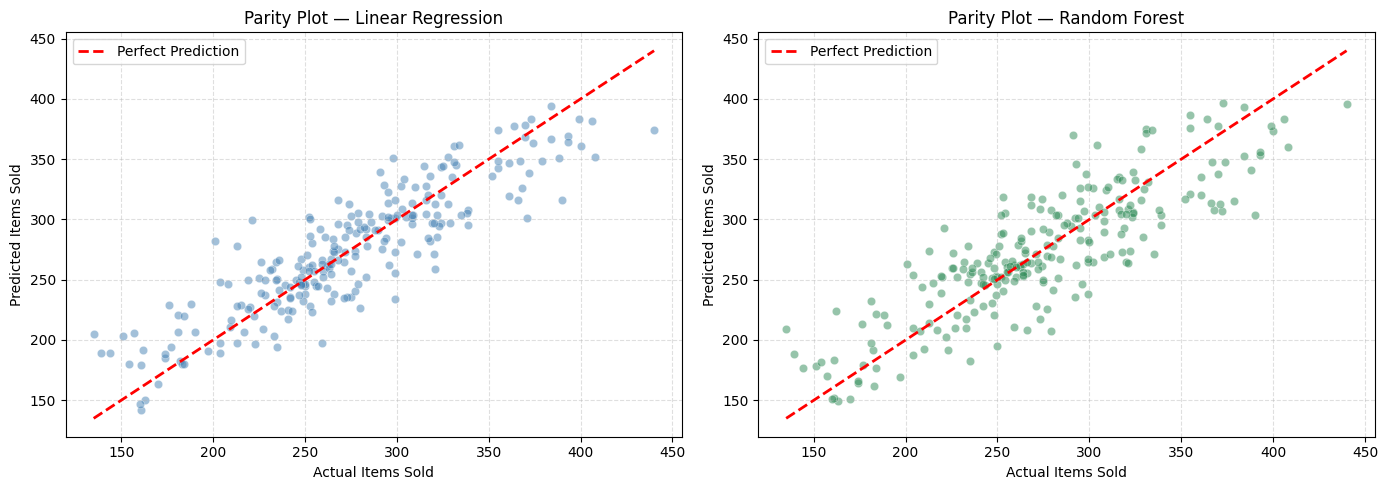

In [8]:
# Parity Plots (Predicted vs Actual)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models      = ['Linear Regression', 'Random Forest']
predictions = [y_pred_lr, y_pred_rf]
colors      = ['steelblue', 'seagreen']

for ax, name, y_pred, color in zip(axes, models, predictions, colors):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color,
               edgecolors='white', linewidths=0.4)

    # Diagonal reference line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect Prediction')

    ax.set_title(f'Parity Plot — {name}')
    ax.set_xlabel('Actual Items Sold')
    ax.set_ylabel('Predicted Items Sold')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [9]:
# Feature names from pipeline
ohe_features = lr_pipeline.named_steps['preprocessor']\
               .named_transformers_['cat']\
               .get_feature_names_out(categorical_features)

all_features = list(ohe_features) + numerical_features

# Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importances — Random Forest:")
print()
print(importance_df.to_string(index=False))
print()
print("Top 5 Most Influential Features:")
print(importance_df.head(5).to_string(index=False))

Feature Importances — Random Forest:

                      Feature  Importance
                  is_festival    0.173552
             store_size_small    0.166445
          location_type_urban    0.109712
                  day_of_week    0.088706
                   is_weekend    0.066189
          competition_density    0.064149
          location_type_rural    0.054804
                        month    0.051572
             store_size_large    0.050357
          promotion_type_bogo    0.032117
            store_size_medium    0.029852
promotion_type_loyalty_points    0.025482
                         year    0.021820
 promotion_type_flat_discount    0.018134
     location_type_semi-urban    0.017416
promotion_type_category_offer    0.012465
     promotion_type_free_gift    0.009852
                 is_month_end    0.007376

Top 5 Most Influential Features:
            Feature  Importance
        is_festival    0.173552
   store_size_small    0.166445
location_type_urban    0.109712
  